In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

energy_files = list(pathlib.Path("extraction/alt_energies").rglob("*.pkl"))
file_to_qubit_count_mapping = {}
for file in energy_files:
    file_stem = str(file.stem)
    str_qubit_count = file.as_posix().split("/")[-2]
    try:
        qubit_count = int(str_qubit_count)
        file_to_qubit_count_mapping[file_stem] = qubit_count
    except ValueError:
        print(f"Warning: Could not convert '{str_qubit_count}' to an integer for file {file_stem}. Skipping this file.")

In [2]:
def get_files_by_folders(results_folders):
    result_paths = []
    for results_folder in results_folders:
        paths = list(pathlib.Path(f"{results_folder}").rglob("*.npz"))
        result_paths.extend(paths)

    return {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in result_paths}

def generate_df_from_files(result_files, file_to_qubit_count_mapping, target_confidence=0.9999):
    data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

    for name, data in result_files.items():
        with open(data["path"], 'rb') as f:
            saved_results = np.load(f, allow_pickle=True)
            result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

        result_files[name]["protein"] = name.split("_")[0]
        result_files[name]["start_residue"] = int(name.split("_")[1])
        result_files[name]["end_residue"] = int(name.split("_")[2])
        result_files[name]["rotamer_count"] = int(name.split("_")[3])
        result_files[name]["qaoa_layers"] = int(name.split("_")[4])

        result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
        result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

        name_without_layers = "_".join(name.split("_")[:-2])
        if name_without_layers in file_to_qubit_count_mapping:
            result_files[name]["num_qubits"] = file_to_qubit_count_mapping[name_without_layers]
        else:
            print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
            result_files[name]["num_qubits"] = None

    target_probs_records = []
    for name, data in result_files.items():
    # if not name.startswith("5PTI_18_22"): continue

        target_probs = result_files[name]["data"]['target_probs']
        # print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

        # Sum across the 16 conformations for each seed
        summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
        # print("Shape after summing across conformations:", summed_probs.shape)


        # Create a record for each seed with its summed probability
        for seed_idx, summed_prob in enumerate(summed_probs):
            if int(summed_prob) == 1: shots_for_target_prob = 1
            else: shots_for_target_prob = np.ceil(np.log(1 - target_confidence) / np.log(1 - summed_prob))
            record = {
                'protein': result_files[name]['protein'],
                'subsection': result_files[name]['subsection'],
                'subsection_length': result_files[name]['subsection_length'],
                'rotamer_count': result_files[name]['rotamer_count'],
                'qaoa_layers': result_files[name]['qaoa_layers'],
                'num_qubits': result_files[name]['num_qubits'],
                'seed': seed_idx,
                'target_prob': summed_prob,  # This is now the sum across all 16 conformations
                'shots_for_target_prob': shots_for_target_prob
            }
            target_probs_records.append(record)

    # Create dataframe from records
    return pd.DataFrame(target_probs_records)

In [14]:
colab_files = get_files_by_folders(["QAOA_Results_Backup 2", "QAOA_Results_Backup_3"])
colab_df = generate_df_from_files(colab_files, file_to_qubit_count_mapping)
colab_df = colab_df[colab_df['num_qubits'] >= 14]
colab_df


,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_target_prob
0,5PTI,15-21,7,5,12,22,0,0.003191,2882.0
1,5PTI,15-21,7,5,12,22,1,0.026477,344.0
2,5PTI,15-21,7,5,12,22,2,0.017021,537.0
3,5PTI,15-21,7,5,12,22,3,0.069033,129.0
4,5PTI,15-21,7,5,12,22,4,0.523586,13.0
...,...,...,...,...,...,...,...,...,...
2255,5PTI,7-12,6,4,8,14,25,0.928336,4.0
2256,5PTI,7-12,6,4,8,14,26,0.971792,3.0
2257,5PTI,7-12,6,4,8,14,27,0.690732,8.0
2258,5PTI,7-12,6,4,8,14,28,0.849217,5.0


In [15]:
local_files = get_files_by_folders(["qaoa/qaoa_runs_5-14_batch1", 'qaoa/qaoa_runs_5-14_batch2'])
local_df = generate_df_from_files(local_files, file_to_qubit_count_mapping)
local_df = local_df[local_df['num_qubits'] <= 14]
local_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_target_prob
0,5PTI,9-11,3,3,8,6,0,0.999999,1.0
1,5PTI,9-11,3,3,8,6,1,1.000000,1.0
2,5PTI,9-11,3,3,8,6,2,0.999887,2.0
3,5PTI,9-11,3,3,8,6,3,1.000000,1.0
4,5PTI,9-11,3,3,8,6,4,0.999798,2.0
...,...,...,...,...,...,...,...,...,...
14995,5PTI,9-14,6,5,4,13,25,0.111249,79.0
14996,5PTI,9-14,6,5,4,13,26,0.084431,105.0
14997,5PTI,9-14,6,5,4,13,27,0.559075,12.0
14998,5PTI,9-14,6,5,4,13,28,0.304424,26.0


/var/folders/01/t57whxgn07b0dg1mhrwgv0kw0000gn/T/ipykernel_66871/3883088608.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=colab_df,


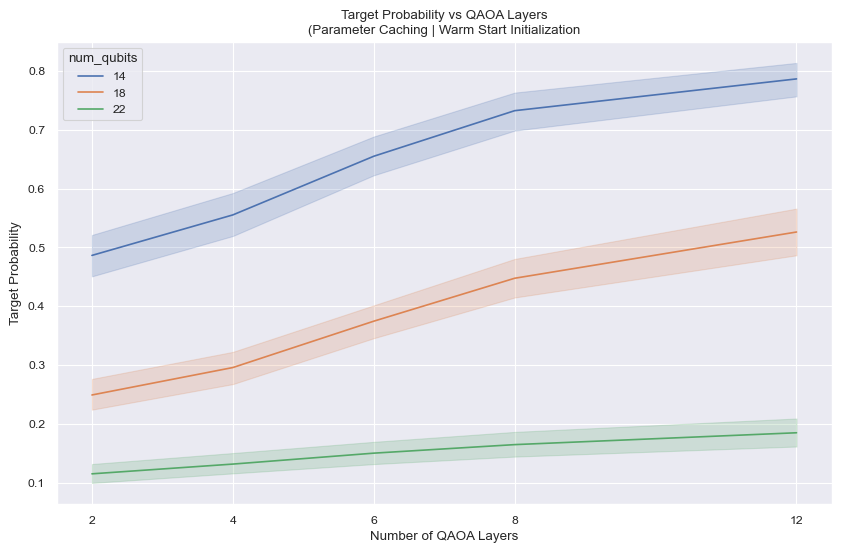

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=colab_df,
             x="qaoa_layers", y="target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=colab_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/colab_probs.svg", dpi=300, bbox_inches='tight')

/var/folders/01/t57whxgn07b0dg1mhrwgv0kw0000gn/T/ipykernel_66871/3828090536.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=colab_df,


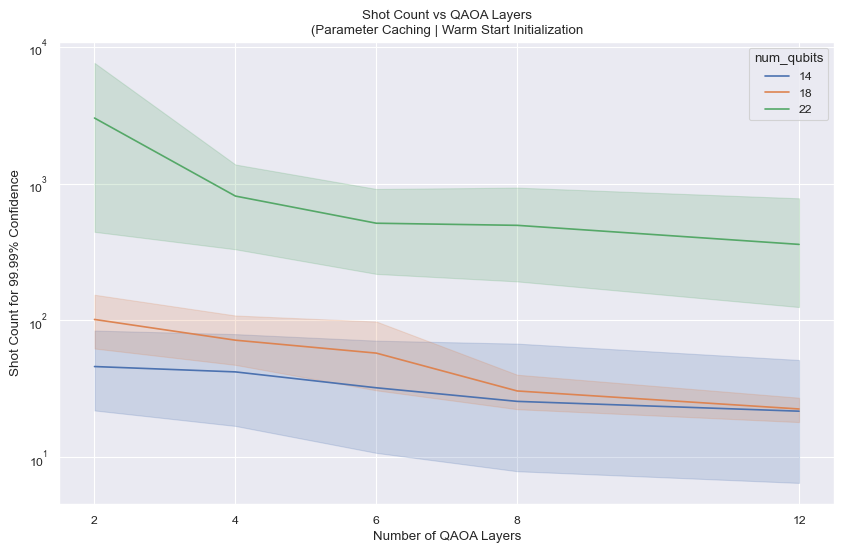

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=colab_df,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=colab_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')

ax.set_title("Shot Count vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Shot Count for 99.99% Confidence")

plt.savefig(f"plots/colab_shots.svg", dpi=300, bbox_inches='tight')

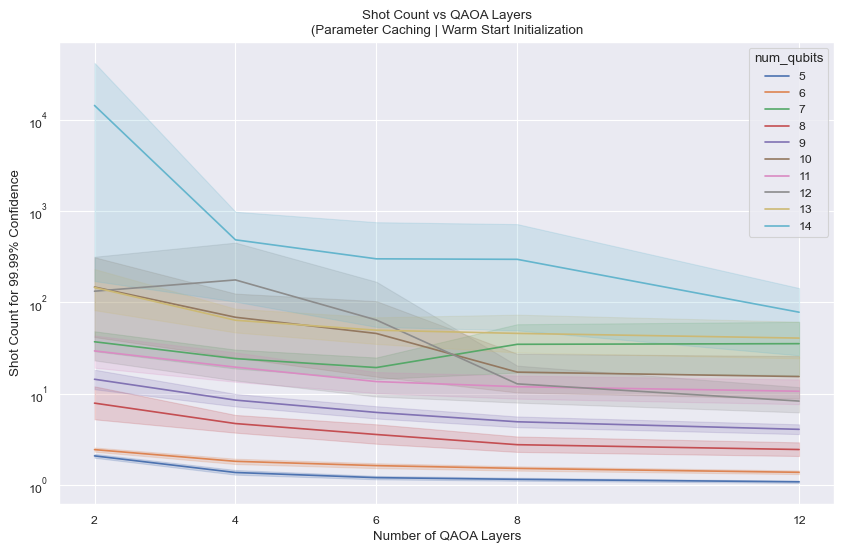

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=local_df,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=local_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')

ax.set_title("Shot Count vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Shot Count for 99.99% Confidence")

plt.savefig(f"plots/local_shots.svg", dpi=300, bbox_inches='tight')

/var/folders/01/t57whxgn07b0dg1mhrwgv0kw0000gn/T/ipykernel_66871/4242028146.py:4: UserWarning: 
The palette list has fewer values (10) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=combined_df,


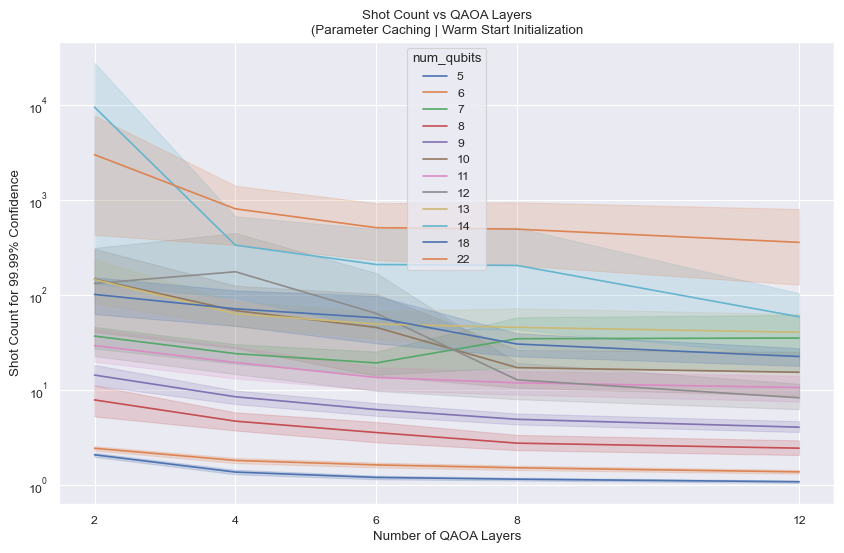

In [18]:
combined_df = pd.concat([colab_df, local_df], ignore_index=True)
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=combined_df,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=combined_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])
ax.set_yscale('log')

ax.set_title("Shot Count vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Shot Count for 99.99% Confidence")

plt.savefig(f"plots/combined_local_colab_shots.svg", dpi=300, bbox_inches='tight')

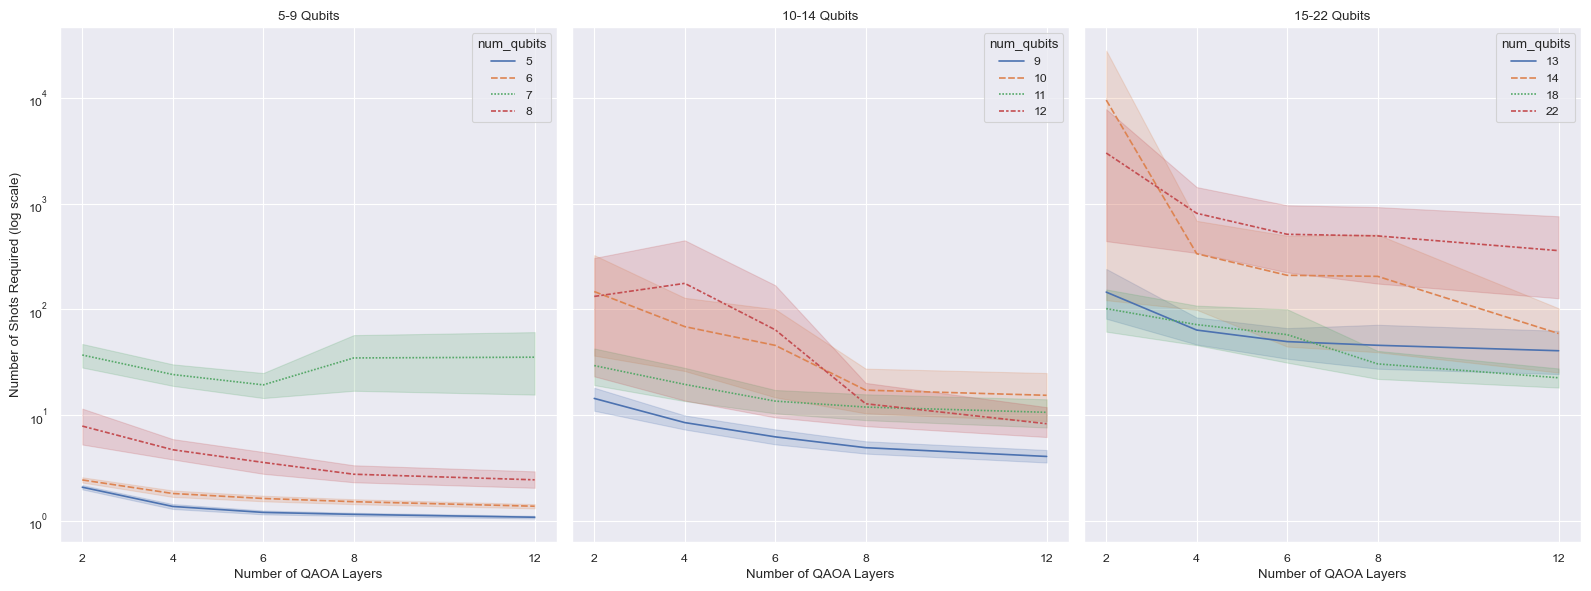

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

data_5_8 = combined_df[(combined_df['num_qubits'] >= 5) & (combined_df['num_qubits'] <= 8)]
data_9_12 = combined_df[(combined_df['num_qubits'] >= 9) & (combined_df['num_qubits'] <= 12)]
data_13_22 = combined_df[(combined_df['num_qubits'] >= 13) & (combined_df['num_qubits'] <= 22)]

sns.lineplot(data=data_5_8,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_5_8['num_qubits'].nunique()),
             ax=ax1)
ax1.set_xticks([2, 4, 6, 8, 12])
ax1.set_title("5-9 Qubits")
ax1.set_ylabel("Number of Shots Required (log scale)")
ax1.set_xlabel("Number of QAOA Layers")

sns.lineplot(data=data_9_12,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_9_12['num_qubits'].nunique()),
             ax=ax2)
ax2.set_xticks([2, 4, 6, 8, 12])
ax2.set_title("10-14 Qubits")
ax2.set_ylabel("Number of Shots Required (log scale)")
ax2.set_xlabel("Number of QAOA Layers")

sns.lineplot(data=data_13_22,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_13_22['num_qubits'].nunique()),
             ax=ax3)

ax3.set_xticks([2, 4, 6, 8, 12])
ax3.set_title("15-22 Qubits")
ax3.set_ylabel("Number of Shots Required (log scale)")
ax3.set_xlabel("Number of QAOA Layers")

# Share the same y-axis limits if desired
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')


plt.tight_layout()
plt.savefig(f"plots/combined_local_colab_shots_split.svg", dpi=300, bbox_inches='tight')